In [1]:
from quickfsfunctions import *
from scipy import stats

## Model Performance Graphs

In [2]:
# Clean raw output data for use in an aggregate figure
df = pd.read_csv("data/experiments/quickFSrankingQuarterlyPrecision+Sharpe+Return2500_0.97", index_col=0)
total_stocks = np.sum(df[df['metric'] == 'all']['stocks picked'])
total_quarters = len(df[df['metric'] == 'all'])
results = pd.DataFrame()
results['metric'] = np.unique(df['metric'])
results['avg pct correct'] = [np.mean(df[df['metric'] == metric]['pct correct']) for metric in results['metric']]
results['std pct correct'] = [np.std(df[df['metric'] == metric]['pct correct']) for metric in results['metric']]
results['avg return'] = [np.mean(df[df['metric'] == metric]['Avg Return']) for metric in results['metric']]
results['std return'] = [np.std(df[df['metric'] == metric]['Avg Return']) for metric in results['metric']]
results['avg sharpe'] = [np.mean(df[df['metric'] == metric]['Sharpe Ratio']) for metric in results['metric']]
results['std sharpe'] = [np.std(df[df['metric'] == metric]['Sharpe Ratio']) for metric in results['metric']]

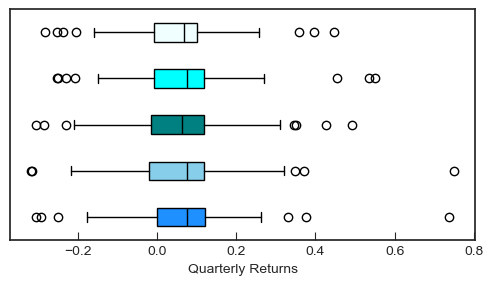

In [103]:
data_list = []
metrics = ["all", "computed", 'balance_sheet', "income_statement", "cash_flow_statement"]
for metric in metrics:
    data_list.append(list(df[df['metric'] == metric]['Avg Return']))

ax = plt.axes()
ax.set_facecolor("white")
fig = plt.gcf()
frame = plt.gca()
fig.set_size_inches(6, 3)
frame.axes.get_yaxis().set_visible(False)

plt.style.use('seaborn-v0_8-ticks')
bplot = plt.boxplot(data_list, vert=False, patch_artist=True, medianprops=dict(color='black'),
            boxprops=dict(facecolor='white'), widths=0.4, showfliers=True)

for patch, color in zip(bplot['boxes'], ['dodgerblue', 'skyblue', 'teal', 'cyan', 'azure']):
    patch.set_facecolor(color)
    
plt.xlabel("Quarterly Returns") # labelsize = 
plt.tick_params(axis='x', which='major', reset=True, direction='in', top=False)
# ax.legend([bplot['boxes'][0], bplot['boxes'][1], bplot['boxes'][2], bplot['boxes'][3], bplot['boxes'][4]], metrics, loc='upper right')
plt.show()

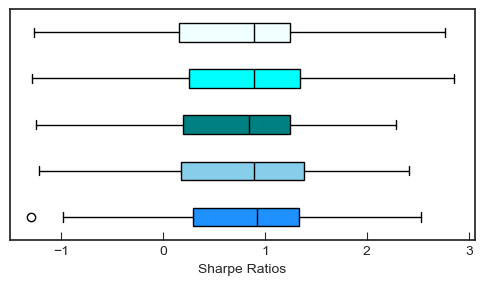

In [102]:
data_list = []
metrics = ["all", "computed", 'balance_sheet', "income_statement", "cash_flow_statement"]
for metric in metrics:
    data_list.append(list(df[df['metric'] == metric]['Sharpe Ratio']))

ax = plt.axes()
ax.set_facecolor("white")
fig = plt.gcf()
frame = plt.gca()
fig.set_size_inches(6, 3)
frame.axes.get_yaxis().set_visible(False)

plt.style.use('seaborn-v0_8-ticks')
bplot = plt.boxplot(data_list, vert=False, patch_artist=True, medianprops=dict(color='black'),
            boxprops=dict(facecolor='white'), widths=0.4, showfliers=True)

for patch, color in zip(bplot['boxes'], ['dodgerblue', 'skyblue', 'teal', 'cyan', 'azure']):
    patch.set_facecolor(color)
    
plt.xlabel("Sharpe Ratios") # labelsize = 
plt.tick_params(axis='x', which='major', reset=True, direction='in', top=False)
# ax.legend([bplot['boxes'][0], bplot['boxes'][1], bplot['boxes'][2], bplot['boxes'][3], bplot['boxes'][4]], metrics, loc='upper right')
plt.show()

In [64]:
def bootstrap_paired_t_test_null(sample1, sample2, n_bootstraps=10000, alternative='two-sided'):
    """
    Perform a bootstrap paired t-test assuming null hypothesis of equal means.
    
    Parameters:
    - sample1, sample2: Paired samples (arrays of equal length)
    - n_bootstraps: Number of bootstrap resamples (default: 10,000)
    - alternative: 'two-sided', 'less', or 'greater' (default: 'two-sided')
    
    Returns:
    - t_obs: Observed t-statistic
    - p_value: Bootstrap p-value
    - bootstrap_dist: Distribution of bootstrap t-statistics under null
    """
    
    # Convert inputs to numpy arrays
    sample1 = np.asarray(sample1)
    sample2 = np.asarray(sample2)
    
    # Check that samples are paired (same length)
    if len(sample1) != len(sample2):
        raise ValueError("Samples must be paired and have the same length")
    
    n = len(sample1)
    differences = sample1 - sample2
    
    # Calculate observed t-statistic
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)  # ddof=1 for sample standard deviation
    t_obs = mean_diff / (std_diff / np.sqrt(n))
    
    # Center the differences under the null hypothesis (mean difference = 0)
    centered_diff = differences - mean_diff
    
    # Bootstrap resampling under null
    bootstrap_t = np.zeros(n_bootstraps)
    
    for i in range(n_bootstraps):
        # Resample with replacement from the centered differences
        resampled_diff = np.random.choice(centered_diff, size=n, replace=True)
        
        # Calculate t-statistic for this resample
        resampled_mean = np.mean(resampled_diff)
        resampled_std = np.std(resampled_diff, ddof=1)
        bootstrap_t[i] = resampled_mean / (resampled_std / np.sqrt(n))
    
    # Calculate p-value based on the alternative hypothesis
    if alternative == 'two-sided':
        p_value = (np.sum(np.abs(bootstrap_t) >= np.abs(t_obs))) / n_bootstraps
    elif alternative == 'less':
        p_value = np.sum(bootstrap_t <= t_obs) / n_bootstraps
    elif alternative == 'greater':
        p_value = np.sum(bootstrap_t >= t_obs) / n_bootstraps
    else:
        raise ValueError("alternative must be 'two-sided', 'less', or 'greater'")
    
    return t_obs, p_value, bootstrap_t


# Example usage:
if __name__ == "__main__":
    # Example data (paired samples)
    before = data[data['metric'] == 'computed']['avg feature importance']
    after = data[data['metric'] == 'balance_sheet']['avg feature importance']
    
    # Perform bootstrap paired t-test under null
    t_obs, p_value, bootstrap_dist = bootstrap_paired_t_test_null(
        before, after, n_bootstraps=10000, alternative='two-sided'
    )
    
    # Compare with traditional paired t-test
    t_classic, p_classic = stats.ttest_rel(before, after)
    
    print("Bootstrap Paired t-test Under Null Hypothesis Results:")
    print(f"Observed t-statistic: {t_obs:.4f}")
    print(f"Bootstrap p-value: {p_value:.4f}")
    print("\nClassical Paired t-test Results:")
    print(f"t-statistic: {t_classic:.4f}")
    print(f"p-value: {p_classic:.4f}")
    
# NOTE: Only the largest diffs in mean quarterly returns and sharpe ratios are significant
'''
samples_A = df[df['metric'] == 'income_statement']['Avg Return']
samples_B = df[df['metric'] == 'cash_flow_statement']['Avg Return']
# samples_A = data[data['metric'] == 'income_statement']['avg feature importance']
# samples_B = data[data['metric'] == 'balance_sheet']['avg feature importance']
# t_obs = 0.8

print(bootstrap_paired_t_test(samples_A, samples_B))
'''

Bootstrap Paired t-test Under Null Hypothesis Results:
Observed t-statistic: 13.1505
Bootstrap p-value: 0.0000

Classical Paired t-test Results:
t-statistic: 13.1505
p-value: 0.0000


"\nsamples_A = df[df['metric'] == 'income_statement']['Avg Return']\nsamples_B = df[df['metric'] == 'cash_flow_statement']['Avg Return']\n# samples_A = data[data['metric'] == 'income_statement']['avg feature importance']\n# samples_B = data[data['metric'] == 'balance_sheet']['avg feature importance']\n# t_obs = 0.8\n\nprint(bootstrap_paired_t_test(samples_A, samples_B))\n"

In [5]:
results

,metric,avg pct correct,std pct correct,avg return,std return,avg sharpe,std sharpe
0,all,0.489496,0.232351,0.061854,0.146985,0.807596,0.832518
1,balance_sheet,0.481780,0.209516,0.055564,0.138624,0.729326,0.767844
2,cash_flow_statement,0.479259,0.222499,0.048302,0.124897,0.766775,0.837730
3,computed,0.492723,0.217227,0.064558,0.151738,0.792188,0.823840
4,income_statement,0.491562,0.209953,0.065833,0.142808,0.800809,0.841109


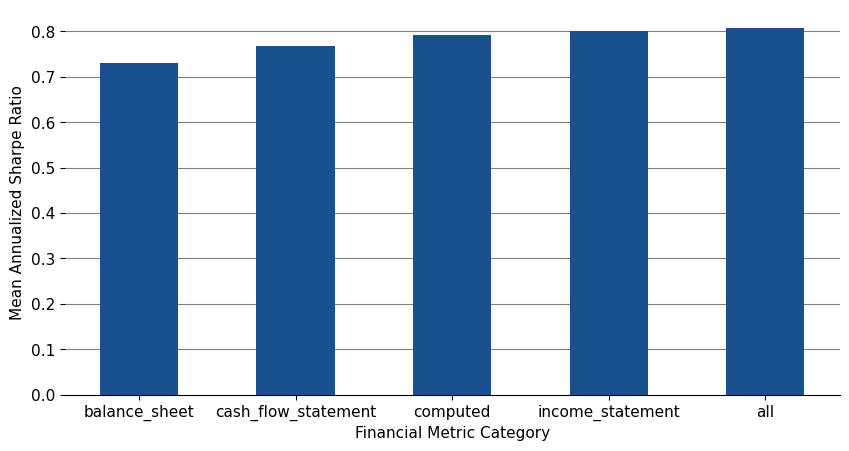

In [11]:
results = results.sort_values("avg sharpe")

# Set universal font size
plt.rcParams['font.size'] = 11

# Display the data for use as a figure
ax = plt.axes()
fig = plt.gcf()
fig.set_size_inches(10, 5)

# Remove the border from the graph
for direction in ['top', 'right', 'left']:
    ax.spines[direction].set_visible(False)
    
ax.set_facecolor("white")
# plt.ylim(2.65, 3.45)
plt.grid(True, axis='y', color='grey')
plt.bar(results['metric'], results['avg sharpe'], width=0.5, color="#195190", zorder=3)
# plt.errorbar(results['metric'], results['avg pct correct'], yerr=results['std pct correct'], capsize=3, linestyle="", color='deepskyblue', zorder=4)
plt.ylabel("Mean Annualized Sharpe Ratio")
plt.xlabel("Financial Metric Category")
plt.show()

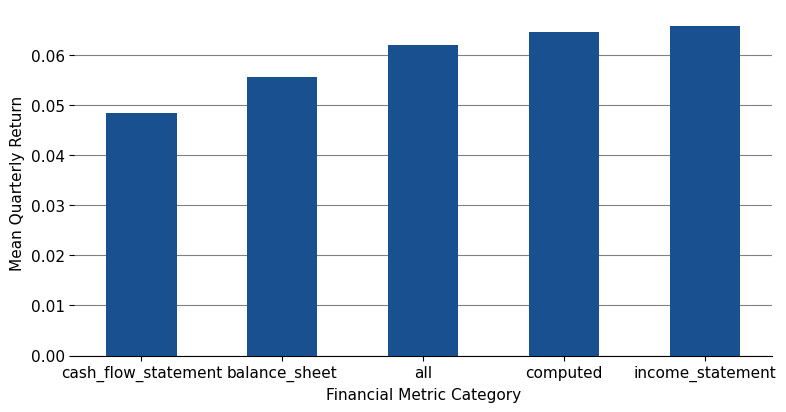

In [12]:
results = results.sort_values("avg return")

# Display the data for use as a figure
ax = plt.axes()
fig = plt.gcf()
fig.set_size_inches(9, 4.5)

# Remove the border from the graph
for direction in ['top', 'right', 'left']:
    ax.spines[direction].set_visible(False)
    
ax.set_facecolor("white")
# plt.ylim(2.65, 3.45)
plt.grid(True, axis='y', color='grey')
plt.bar(results['metric'], results['avg return'], width=0.5, color="#195190", zorder=3)
# plt.errorbar(results['metric'], results['avg pct correct'], yerr=results['std pct correct'], capsize=3, linestyle="", color='deepskyblue', zorder=4)
plt.ylabel("Mean Quarterly Return")
plt.xlabel("Financial Metric Category")
plt.show()

## Feature Importance Graphs

In [34]:
data = pd.read_csv("data/experiments/featureImportance.csv", index_col=0)
for date in np.unique(data['start date']):
    total_importance = sum(list(data[data['start date'] == date]['avg feature importance']))
    for metric in ["computed", 'balance_sheet', "income_statement", "cash_flow_statement"]:
        value = data[(data['start date'] == date) & (data['metric'] == metric)]['avg feature importance'].iloc[0]
        index = data[(data['start date'] == date) & (data['metric'] == metric)].index[0]
        data.loc[index, 'avg feature importance'] = value / total_importance
data

,metric,start date,avg feature importance,# in top 10
0,income_statement,2004-01-01,0.229211,1
1,balance_sheet,2004-01-01,0.223873,2
2,cash_flow_statement,2004-01-01,0.174090,0
3,computed,2004-01-01,0.372827,7
4,income_statement,2004-04-01,0.227095,2
...,...,...,...,...
315,computed,2023-07-01,0.334170,6
316,income_statement,2023-10-01,0.192056,0
317,balance_sheet,2023-10-01,0.287506,2
318,cash_flow_statement,2023-10-01,0.174372,0


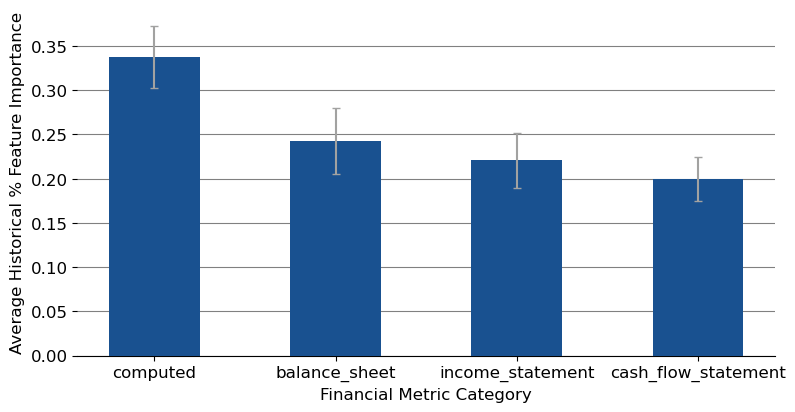

In [36]:
# data = pd.read_csv("data/experiments/featureImportance.csv", index_col=0)
metrics = ["computed", 'balance_sheet', "income_statement", "cash_flow_statement"]
feature_importance = [np.mean(data[data['metric'] == metric]['avg feature importance']) for metric in metrics]
std = [np.std(data[data['metric'] == metric]['avg feature importance']) for metric in metrics]

# feature_importance = feature_importance / feature_importance[0]

# Set universal font size
plt.rcParams['font.size'] = 12

# Display the data for use as a figure
ax = plt.axes()
fig = plt.gcf()
fig.set_size_inches(9, 4.5)

# Remove the border from the graph
for direction in ['top', 'right', 'left']:
    ax.spines[direction].set_visible(False)
    
ax.set_facecolor("white")
plt.grid(True, axis='y', color='grey')
plt.bar(metrics, feature_importance, width=0.5, color='#195190', zorder=3)
plt.errorbar(metrics, feature_importance, yerr=std, capsize=3, linestyle="", color='#A2A2A1', zorder=4)
plt.ylabel("Average Historical % Feature Importance")
plt.xlabel("Financial Metric Category")
plt.show()

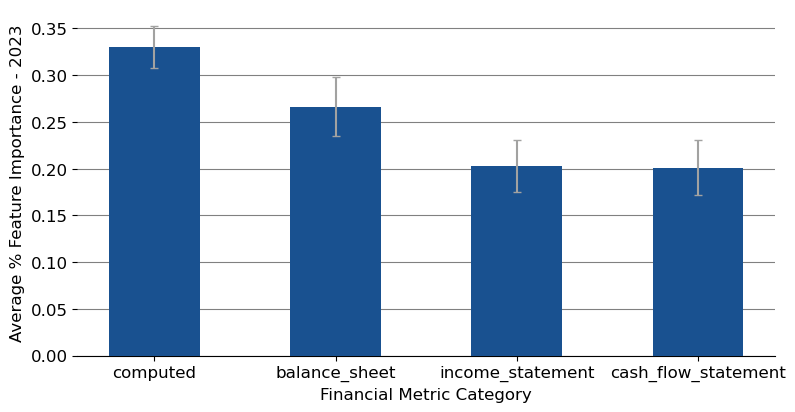

In [37]:
# data = pd.read_csv("data/experiments/featureImportance.csv", index_col=0)
data = data[data['start date'] > '2022-10-01']
metrics = ["computed", 'balance_sheet', "income_statement", "cash_flow_statement"]
feature_importance = [np.mean(data[data['metric'] == metric]['avg feature importance']) for metric in metrics]
std = [np.std(data[data['metric'] == metric]['avg feature importance']) for metric in metrics]

# feature_importance = feature_importance / feature_importance[0]

# Set universal font size
plt.rcParams['font.size'] = 12

# Display the data for use as a figure
ax = plt.axes()
fig = plt.gcf()
fig.set_size_inches(9, 4.5)

# Remove the border from the graph
for direction in ['top', 'right', 'left']:
    ax.spines[direction].set_visible(False)
    
ax.set_facecolor("white")
plt.grid(True, axis='y', color='grey')
plt.bar(metrics, feature_importance, width=0.5, color='#195190', zorder=3)
plt.errorbar(metrics, feature_importance, yerr=std, capsize=3, linestyle="", color='#A2A2A1', zorder=4)
plt.ylabel("Average % Feature Importance - 2023")
plt.xlabel("Financial Metric Category")
plt.show()

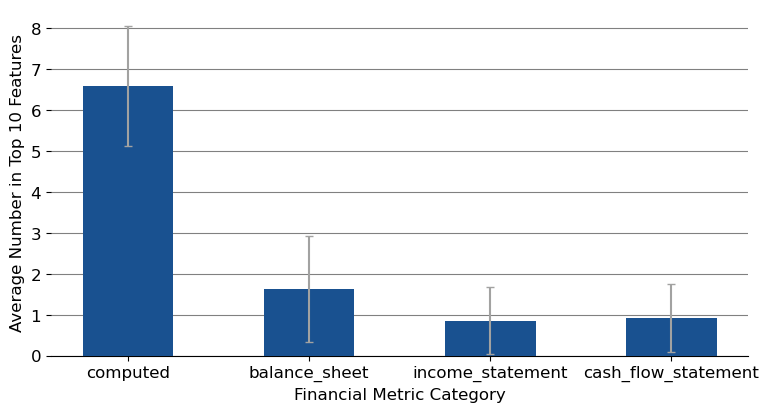

In [16]:
data = pd.read_csv("data/experiments/featureImportance.csv", index_col=0)
metrics = ["computed", 'balance_sheet', "income_statement", "cash_flow_statement"]
feature_importance = [np.mean(data[data['metric'] == metric]['# in top 10']) for metric in metrics]
std = [np.std(data[data['metric'] == metric]['# in top 10']) for metric in metrics]

# Display the data for use as a figure
ax = plt.axes()
fig = plt.gcf()
fig.set_size_inches(9, 4.5)

# Remove the border from the graph
for direction in ['top', 'right', 'left']:
    ax.spines[direction].set_visible(False)
    
ax.set_facecolor("white")
plt.grid(True, axis='y', color='grey')
plt.bar(metrics, feature_importance, width=0.5, color='#195190', zorder=3)
plt.errorbar(metrics, feature_importance, yerr=std, capsize=3, linestyle="", color='#A2A2A1', zorder=4)
plt.ylabel("Average Number in Top 10 Features")
plt.xlabel("Financial Metric Category")
plt.show()

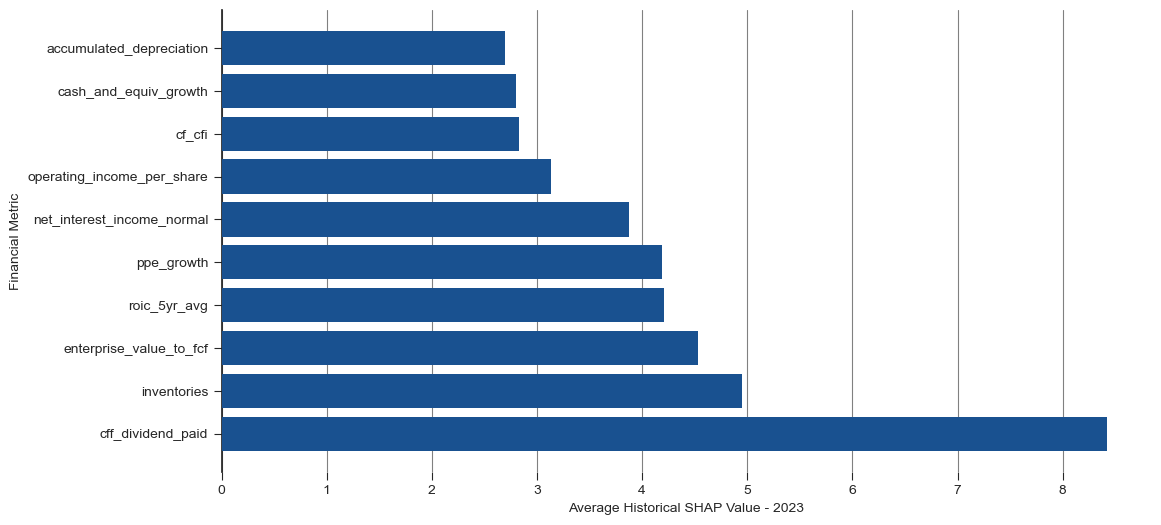

In [169]:
data = pd.read_csv("data/experiments/featureImportanceAllFeatures.csv", index_col=0)
data = data[data['start date'] > '2022-10-01']
averages = pd.DataFrame()
averages['metric'], averages['score'] = [], []
for metric in np.unique(data['metric']):
    averages.loc[len(averages)] = [metric, np.mean(data[data['metric'] == metric]['feature importance'])]

important_features = averages.nlargest(10, columns="score")

# Display the data for use as a figure
ax = plt.axes()
fig = plt.gcf()
fig.set_size_inches(12, 6)

# Remove the border from the graph
for direction in ['top', 'right', 'bottom']:
    ax.spines[direction].set_visible(False)
    
ax.set_facecolor("white")
plt.grid(True, axis='x', color='grey')
plt.barh(important_features['metric'], important_features['score'], color='#195190', zorder=3)
plt.xlabel("Average Historical SHAP Value - 2023")
plt.ylabel("Financial Metric")
plt.show()

Historically, the model is able to balance various fundamental metrics that track revenue, expenses, profit, value, return for investors, and growth.

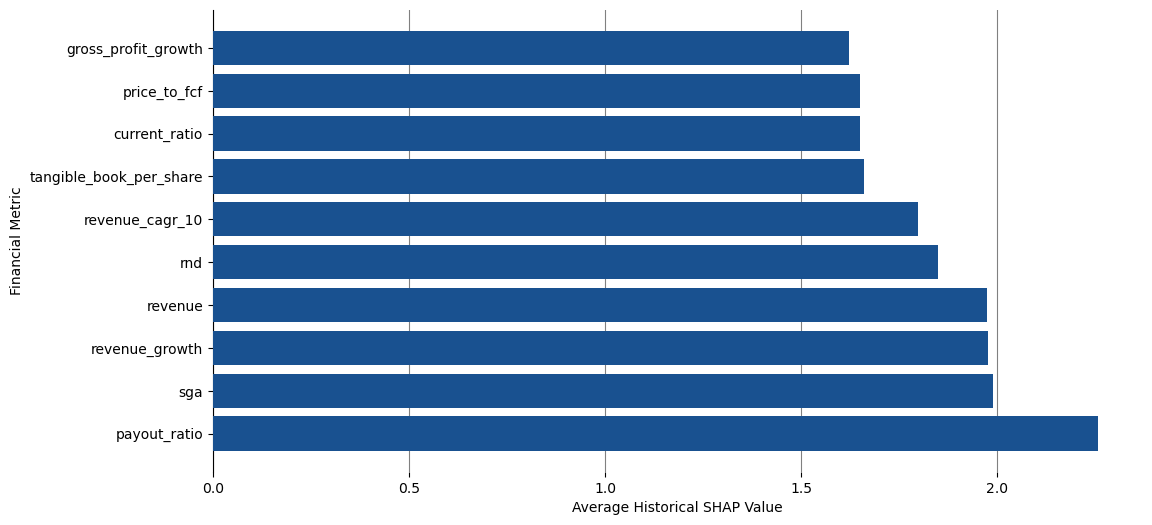

In [4]:
data = pd.read_csv("data/experiments/featureImportanceAllFeatures.csv", index_col=0)
# data = data[data['start date'] > '2022-10-01']

averages = pd.DataFrame()
averages['metric'], averages['score'] = [], []
for metric in np.unique(data['metric']):
    averages.loc[len(averages)] = [metric, np.mean(data[data['metric'] == metric]['feature importance'])]

important_features = averages.nlargest(10, columns="score")

# Display the data for use as a figure
ax = plt.axes()
fig = plt.gcf()
fig.set_size_inches(12, 6)

# Remove the border from the graph
for direction in ['top', 'right', 'bottom']:
    ax.spines[direction].set_visible(False)
    
ax.set_facecolor("white")
plt.grid(True, axis='x', color='grey')
plt.barh(important_features['metric'], important_features['score'], color='#195190', zorder=3)
plt.xlabel("Average Historical SHAP Value")
plt.ylabel("Financial Metric")
plt.show()

However, over the most recent year, the model has focused on metrics that describe funds raised from investors, overall profitability, income, and growth or depreciation of assets. This demonstrates how the model can learn what features are most important at a given time and adapt to different market conditions as they arise.

In [107]:
data = pd.read_csv("data/experiments/featureImportance.csv", index_col=0)
metrics = ["computed", 'balance_sheet', "income_statement", "cash_flow_statement"]


WS_stat, p_value = stats.wilcoxon(data[data['metric'] == 'income_statement']['avg feature importance'], data[data['metric'] == 'cash_flow_statement']['avg feature importance'], alternative='two-sided')
print("W:", WS_stat)
print("p value:", p_value)

W: 935.0
p value: 0.0010181718082251704


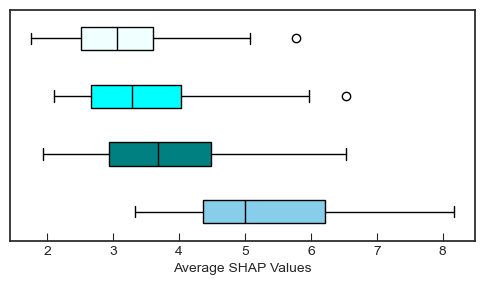

In [104]:
data_list = []
metrics = ["computed", 'balance_sheet', "income_statement", "cash_flow_statement"]
for metric in metrics:
    data_list.append(list(data[data['metric'] == metric]['avg feature importance']))

ax = plt.axes()
ax.set_facecolor("white")
fig = plt.gcf()
frame = plt.gca()
fig.set_size_inches(6, 3)
frame.axes.get_yaxis().set_visible(False)

plt.style.use('seaborn-v0_8-ticks')
bplot = plt.boxplot(data_list, vert=False, patch_artist=True, medianprops=dict(color='black'),
            boxprops=dict(facecolor='white'), widths=0.4, showfliers=True)

for patch, color in zip(bplot['boxes'], ['skyblue', 'teal', 'cyan', 'azure']):
    patch.set_facecolor(color)
    
plt.xlabel("Average SHAP Values") # labelsize = 
plt.tick_params(axis='x', which='major', reset=True, direction='in', top=False)
# ax.legend([bplot['boxes'][0], bplot['boxes'][1], bplot['boxes'][2], bplot['boxes'][3], bplot['boxes'][4]], metrics, loc='upper right')
plt.show()